先尝试用均匀分布模型来拟合样本：

c:\Users\22130\anaconda3\envs\si100\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\22130\anaconda3\envs\si100\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\22130\anaconda3\envs\si100\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\22130\anaconda3\envs\si100\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\22130\anaconda3\envs\si100\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK U

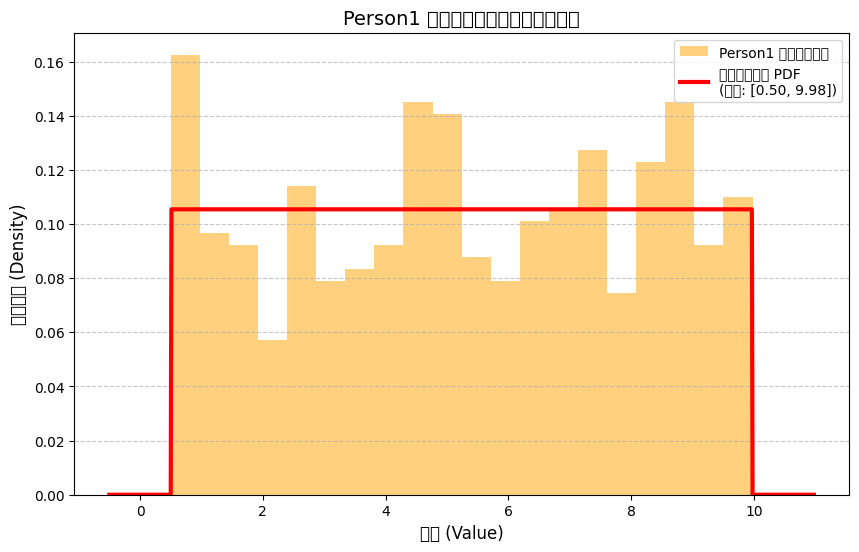

拟合结果：
最小值 (a): 0.5000
最大值 (b): 9.9800
区间长度 (b-a): 9.4800


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

df = pd.read_csv('envelopes.csv')



# 2. 数据清洗：剔除最后一行 "Total"
df_clean = df.iloc[:-1].copy()

# 确保 Person1 列为浮点数类型
person1_values = df_clean['Person1'].astype(float)

# 3. 使用均匀分布拟合数据
# uniform.fit 返回 (loc, scale)，其中 loc 是起点 a，scale 是区间长度 (b - a)
a_fit, scale_fit = uniform.fit(person1_values)
b_fit = a_fit + scale_fit

# 4. 绘图
plt.figure(figsize=(10, 6))

# 绘制直方图（density=True 保证纵坐标为概率密度）
plt.hist(person1_values, bins=20, density=True, alpha=0.5, color='orange', label='Person1 ')

# 生成拟合的 PDF 曲线
x = np.linspace(a_fit - 1, b_fit + 1, 1000)
pdf = uniform.pdf(x, loc=a_fit, scale=scale_fit)
plt.plot(x, pdf, 'r-', lw=3, label=f'拟合均匀分布 PDF\n(区间: [{a_fit:.2f}, {b_fit:.2f}])')

# 设置图表细节
plt.title('Person1 ', fontsize=14)
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 输出拟合参数
print(f"拟合结果：")
print(f"最小值 (a): {a_fit:.4f}")
print(f"最大值 (b): {b_fit:.4f}")
print(f"区间长度 (b-a): {scale_fit:.4f}")